In [27]:
print("HELLO")

HELLO


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\User\My Drive\Shopper spectrum
['cleaned data.ipynb', 'cleaned_online_retail.csv', 'online_retail.csv']


In [30]:
import pandas as pd

df = pd.read_csv("online_retail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2023-12-09 12:50:00,4.95,12680.0,France


In [32]:
df.shape

(541909, 8)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [34]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [35]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(5268)

In [37]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [38]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [39]:
# Remove duplicates
df = df.drop_duplicates()

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [42]:
# Remove invalid Quantity
df = df[df['Quantity'] > 0]

In [43]:
# Remove invalid UnitPrice
df = df[df['UnitPrice'] > 0]

In [44]:
# Convert InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [45]:
# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [46]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 49.2 MB


In [48]:
df.shape

(392692, 9)

In [49]:
df.to_csv("cleaned_online_retail.csv", index=False)

In [51]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayName'] = df['InvoiceDate'].dt.day_name()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2022,12,1,Thursday
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022,12,1,Thursday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2022,12,1,Thursday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022,12,1,Thursday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022,12,1,Thursday


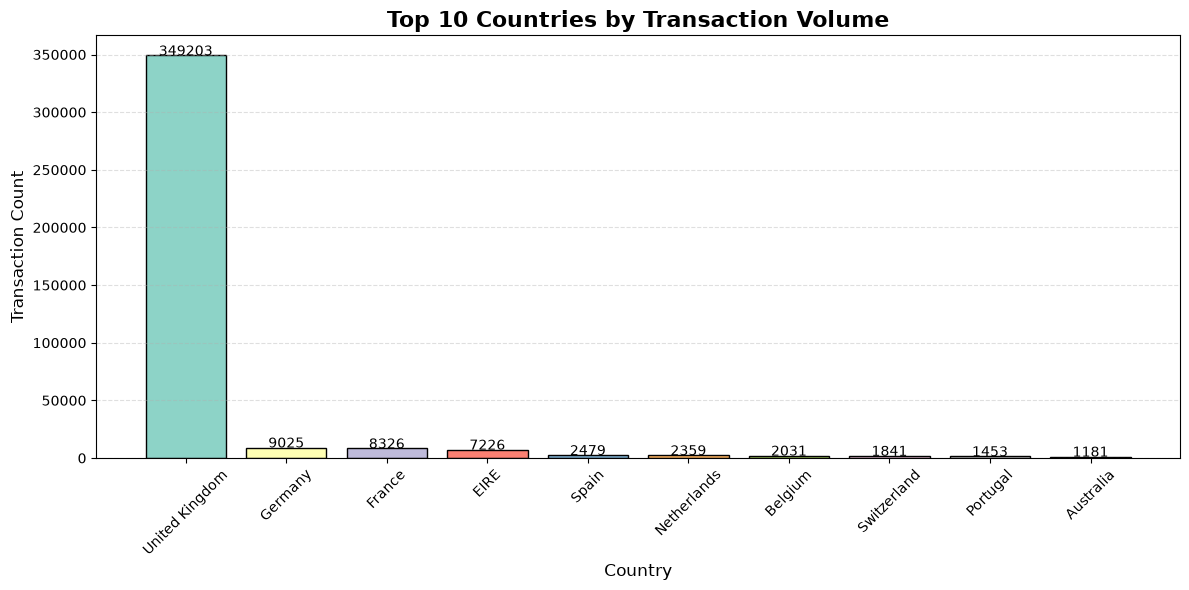

In [53]:
import matplotlib.pyplot as plt

country = df['Country'].value_counts().head(10)

colors = plt.cm.Set3(range(len(country)))

plt.figure(figsize=(12,6))

plt.bar(country.index, country.values, color=colors, edgecolor='black')

plt.title("Top 10 Countries by Transaction Volume", fontsize=16, fontweight='bold')
plt.xlabel("Country", fontsize=12)
plt.ylabel("Transaction Count", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(country.values):
    plt.text(i, value + 50, str(value), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

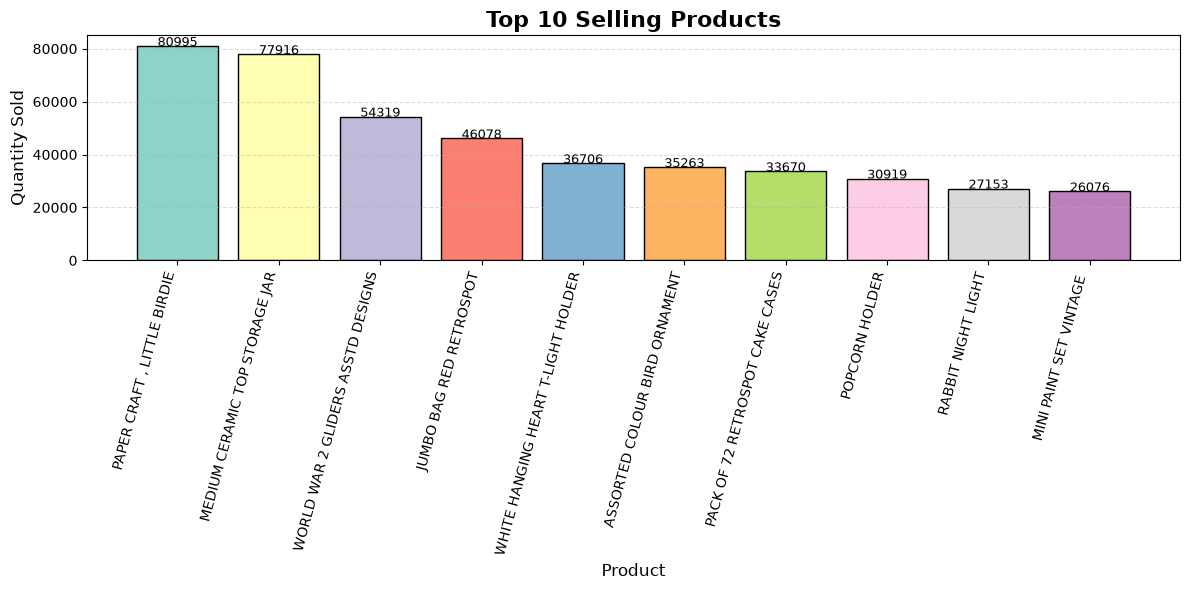

In [55]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

colors = plt.cm.Set3(range(len(top_products)))

plt.figure(figsize=(12,6))

plt.bar(top_products.index, top_products.values,
        color=colors,
        edgecolor='black')

plt.title("Top 10 Selling Products", fontsize=16, fontweight='bold')
plt.xlabel("Product", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)

plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(top_products.values):
    plt.text(i, value, str(value),
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.show()

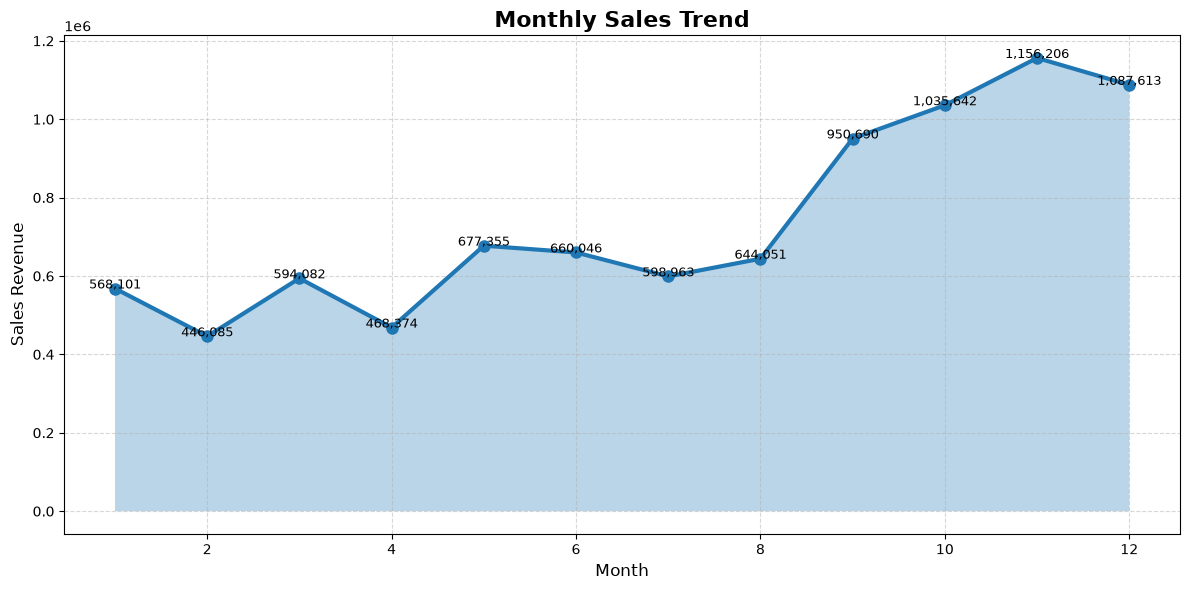

In [57]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=3,
         markersize=8)

plt.fill_between(monthly_sales.index,
                 monthly_sales.values,
                 alpha=0.3)

plt.title("Monthly Sales Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales Revenue", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(x, y, f"{y:,.0f}",
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.show()

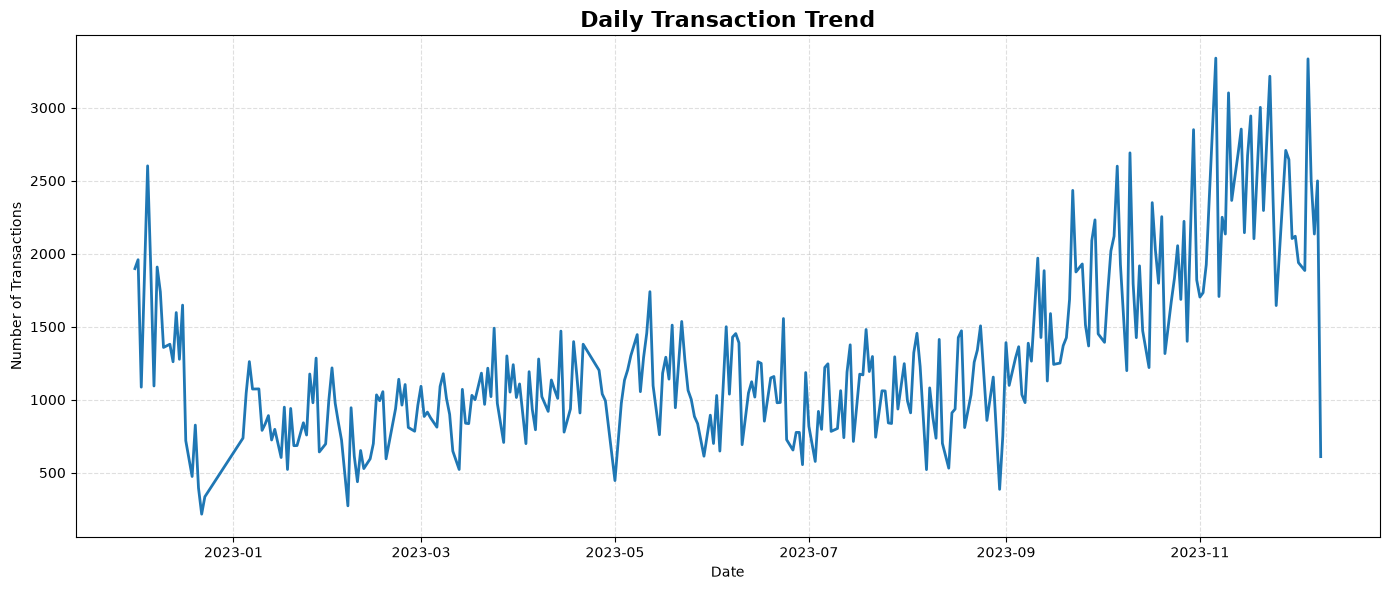

In [58]:
daily_transactions = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].count()

plt.figure(figsize=(14,6))

plt.plot(daily_transactions.index,
         daily_transactions.values,
         linewidth=2)

plt.title("Daily Transaction Trend", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

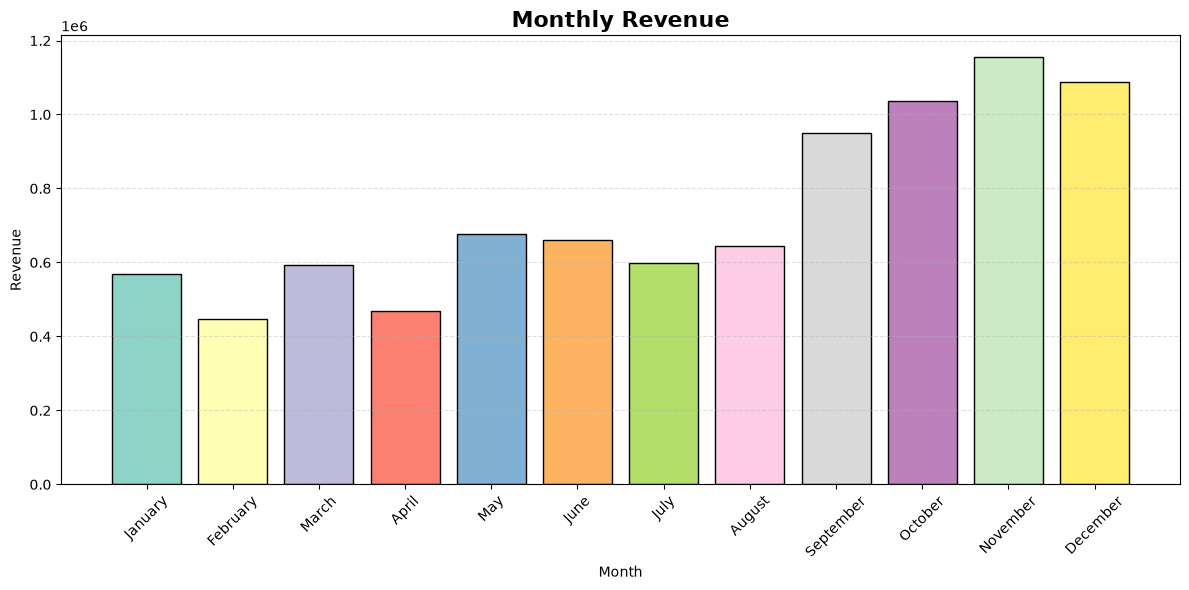

In [59]:
monthly_revenue = df.groupby(df['InvoiceDate'].dt.month_name())['TotalPrice'].sum()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_revenue = monthly_revenue.reindex(month_order)

colors = plt.cm.Set3(range(len(monthly_revenue)))

plt.figure(figsize=(12,6))

plt.bar(monthly_revenue.index,
        monthly_revenue.values,
        color=colors,
        edgecolor='black')

plt.title("Monthly Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

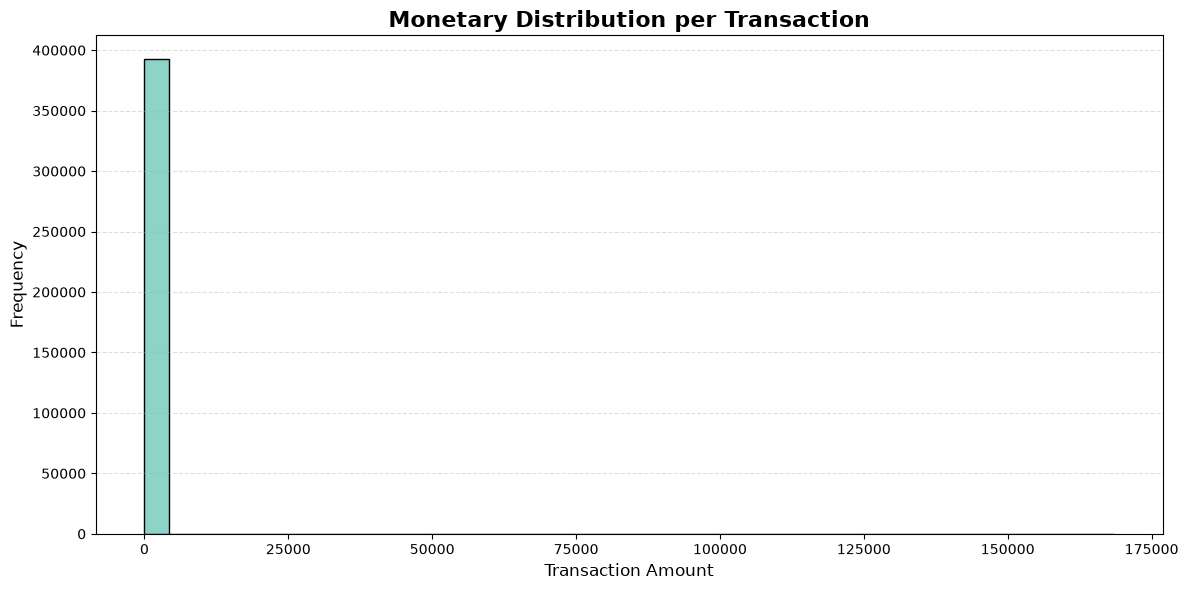

In [60]:
plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(df['TotalPrice'],
                                 bins=40,
                                 edgecolor='black')

# Different colors for each bar
colors = plt.cm.Set3(range(len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Monetary Distribution per Transaction",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Transaction Amount", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [63]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2022,12,1,Thursday
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022,12,1,Thursday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2022,12,1,Thursday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022,12,1,Thursday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022,12,1,Thursday


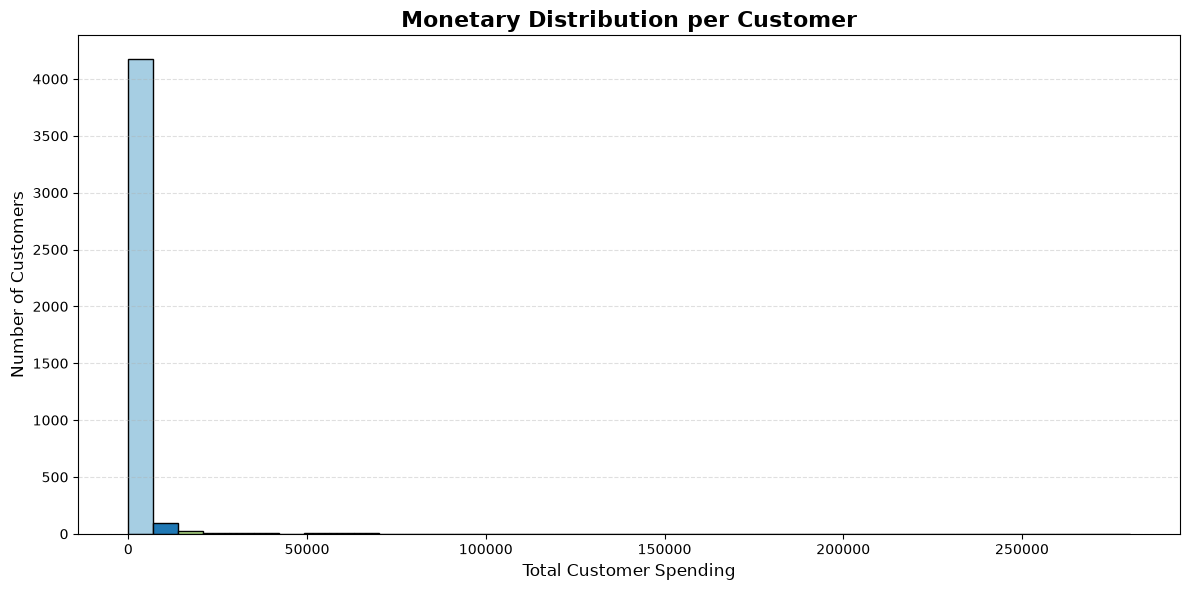

In [64]:
plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(customer_spending,
                                 bins=40,
                                 edgecolor='black')

# Different colors for each bar
colors = plt.cm.Paired(range(len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Monetary Distribution per Customer",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Total Customer Spending", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

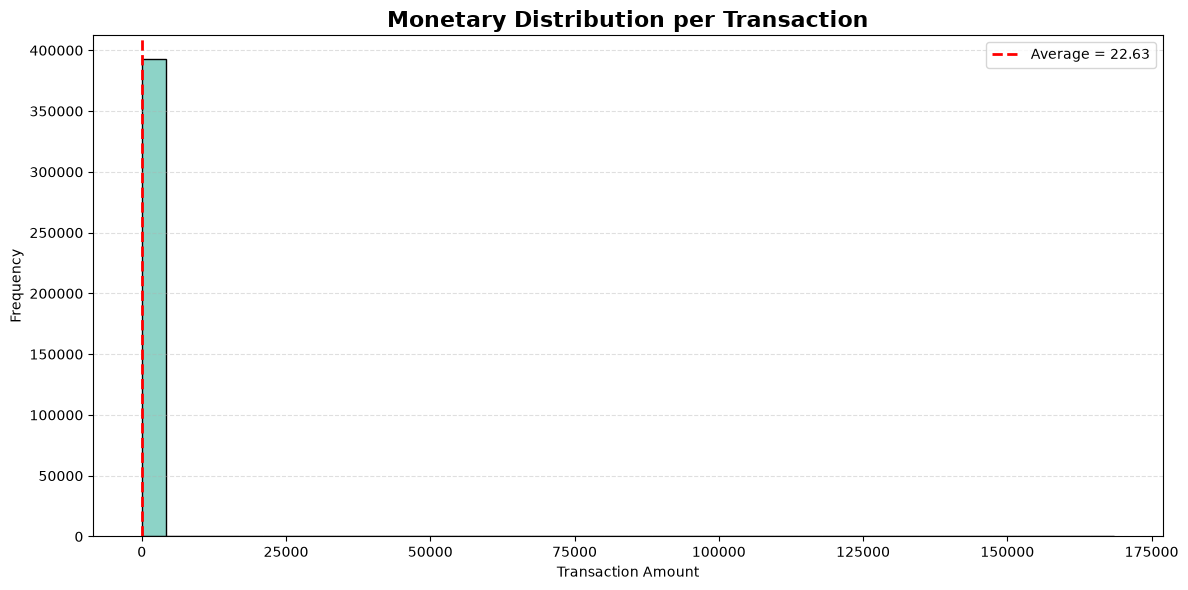

In [65]:
plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(df['TotalPrice'],
                                 bins=40,
                                 edgecolor='black')

colors = plt.cm.Set3(range(len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

avg = df['TotalPrice'].mean()

plt.axvline(avg,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Average = {avg:.2f}')

plt.title("Monetary Distribution per Transaction",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [66]:
# Reference date (one day after the latest transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first 5 rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [67]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [68]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


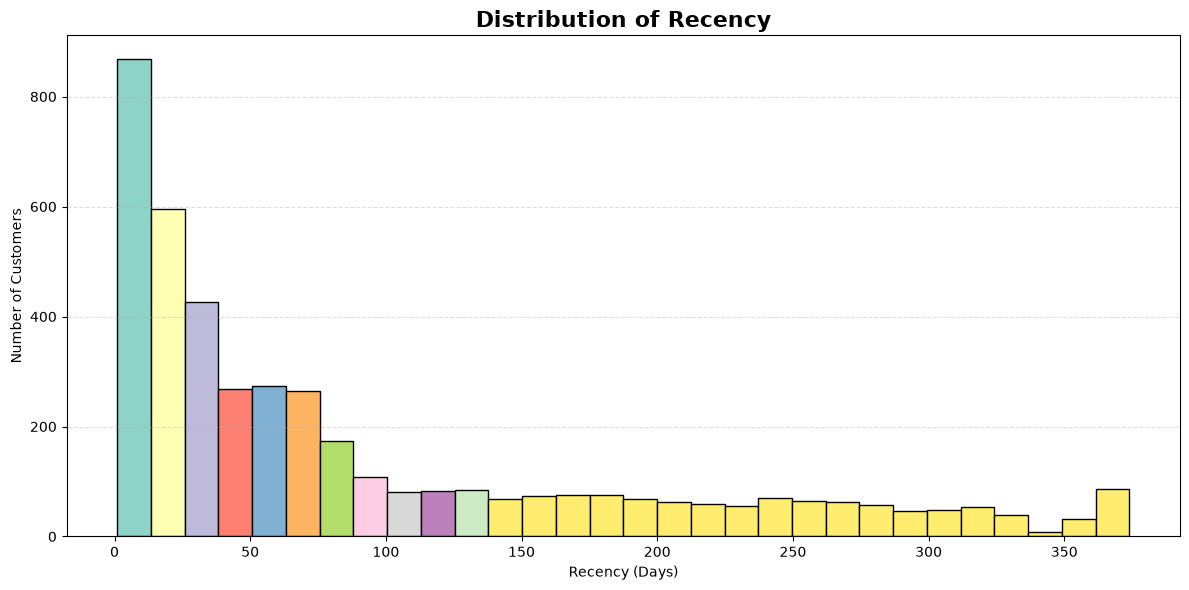

In [69]:
plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(rfm['Recency'],
                                 bins=30,
                                 edgecolor='black')

colors = plt.cm.Set3(range(len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Distribution of Recency",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

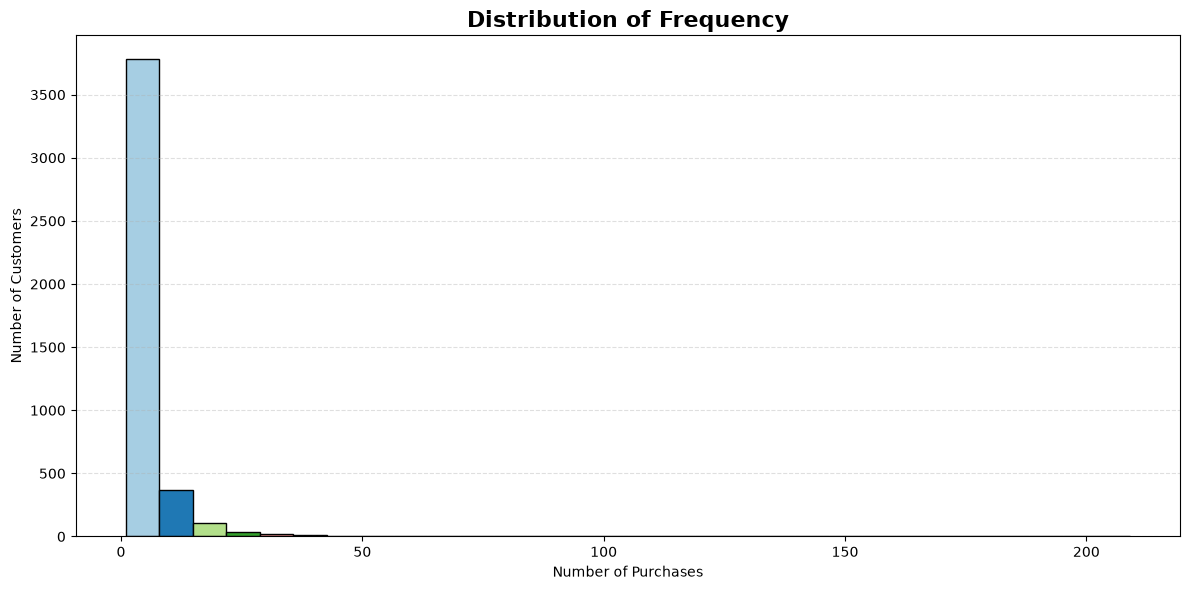

In [70]:
plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(rfm['Frequency'],
                                 bins=30,
                                 edgecolor='black')

colors = plt.cm.Paired(range(len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Distribution of Frequency",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

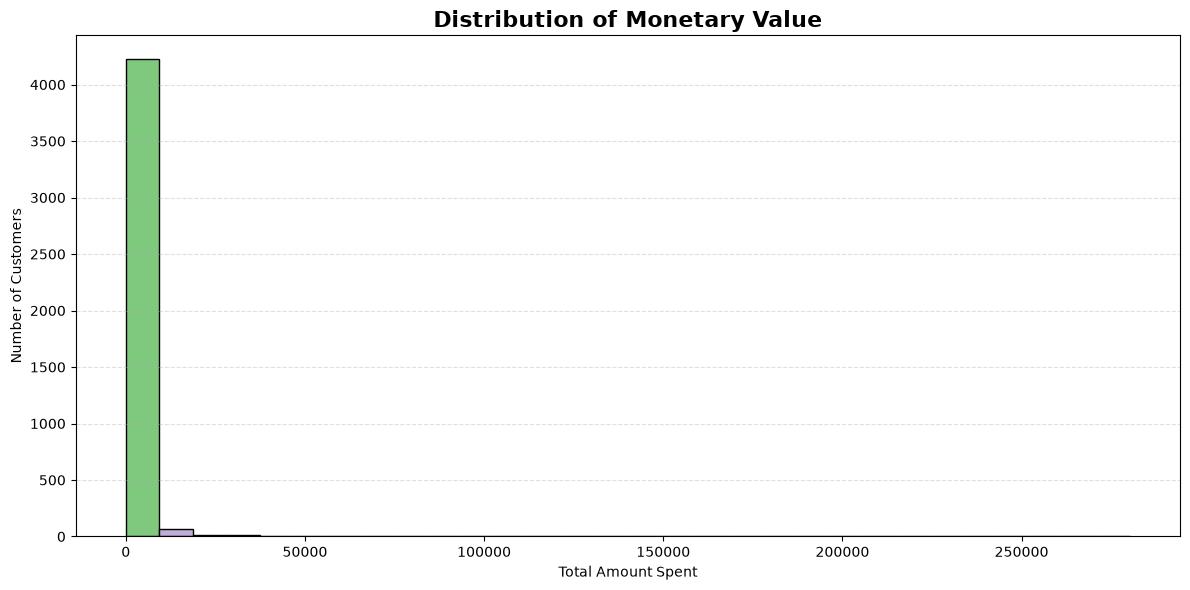

In [71]:
plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(rfm['Monetary'],
                                 bins=30,
                                 edgecolor='black')

colors = plt.cm.Accent(range(len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)

plt.title("Distribution of Monetary Value",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Total Amount Spent")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [74]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the RFM values
rfm_scaled = scaler.fit_transform(rfm)

# Convert to DataFrame for better readability
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


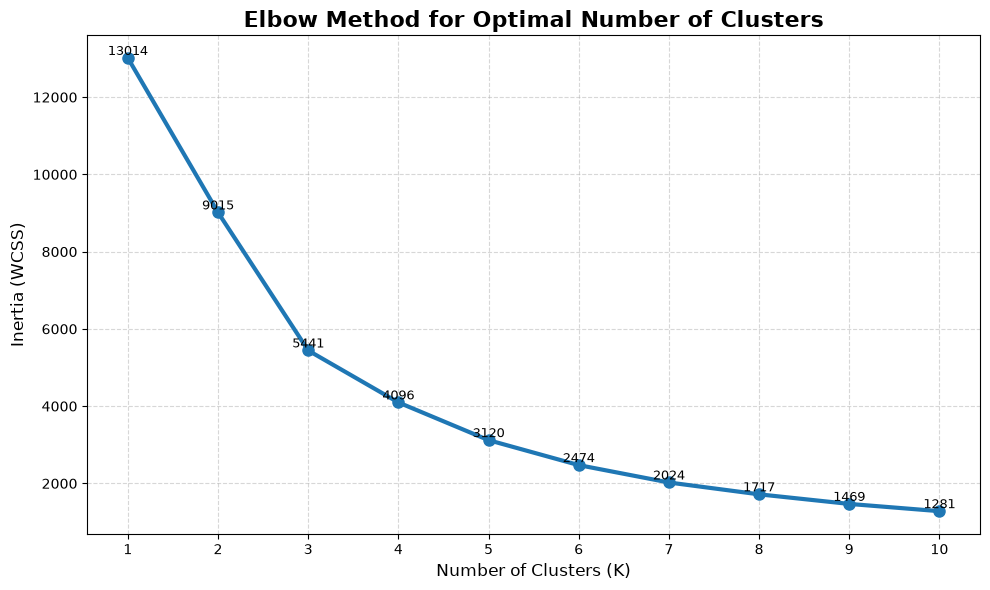

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store inertia values
inertia = []

# Try different values of K
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))

plt.plot(K,
         inertia,
         marker='o',
         linewidth=3,
         markersize=8)

plt.title("Elbow Method for Optimal Number of Clusters",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (WCSS)", fontsize=12)

plt.xticks(K)
plt.grid(True, linestyle='--', alpha=0.5)

# Add value labels
for x, y in zip(K, inertia):
    plt.text(x, y, f"{y:.0f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
from sklearn.cluster import KMeans

# Train K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Predict cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first few rows
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [77]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [78]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [79]:
from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit model and predict clusters
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first few rows
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [80]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [81]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [82]:
cluster_labels = {
    0: 'Occasional',
    1: 'At-Risk',
    2: 'High-Value',
    3: 'Regular'
}

rfm['Customer Segment'] = rfm['Cluster'].map(cluster_labels)

rfm.head()


,Recency,Frequency,Monetary,Cluster,Customer Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular
12347.0,2,7,4310.00,0,Occasional
12348.0,75,4,1797.24,0,Occasional
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,1,At-Risk


In [83]:
cluster_summary = rfm.groupby('Customer Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Customer Segment,,,
At-Risk,248.08,1.55,478.85
High-Value,7.38,82.54,127187.96
Occasional,43.70,3.68,1353.63
Regular,15.50,22.33,12690.50


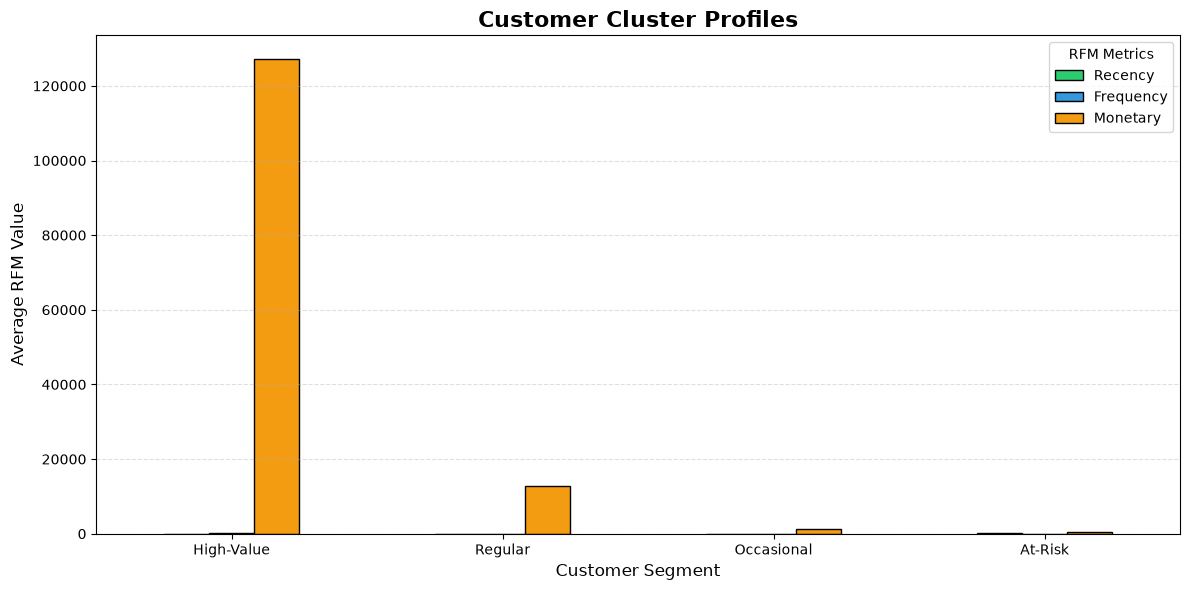

In [84]:
import matplotlib.pyplot as plt
import numpy as np

cluster_summary = cluster_summary.loc[['High-Value',
                                       'Regular',
                                       'Occasional',
                                       'At-Risk']]

colors = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']

ax = cluster_summary.plot(kind='bar',
                          figsize=(12,6),
                          color=colors,
                          edgecolor='black')

plt.title("Customer Cluster Profiles",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Average RFM Value", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="RFM Metrics")

plt.tight_layout()
plt.show()

In [85]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [86]:
from sklearn.metrics.pairwise import cosine_similarity

In [87]:
product_similarity = cosine_similarity(customer_product_matrix.T)

In [88]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product_matrix.columns,
    columns=customer_product_matrix.columns
)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.0,0.001376,0.015917,0.001771,0.0,0.002852,0.0,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.0,0.001726,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.0,0.000044,0.002869,0.344928,0.0,0.525868,0.0,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.0,0.001416,0.004198,0.310053,0.0,0.471772,0.0,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837176,0.000000,0.000000


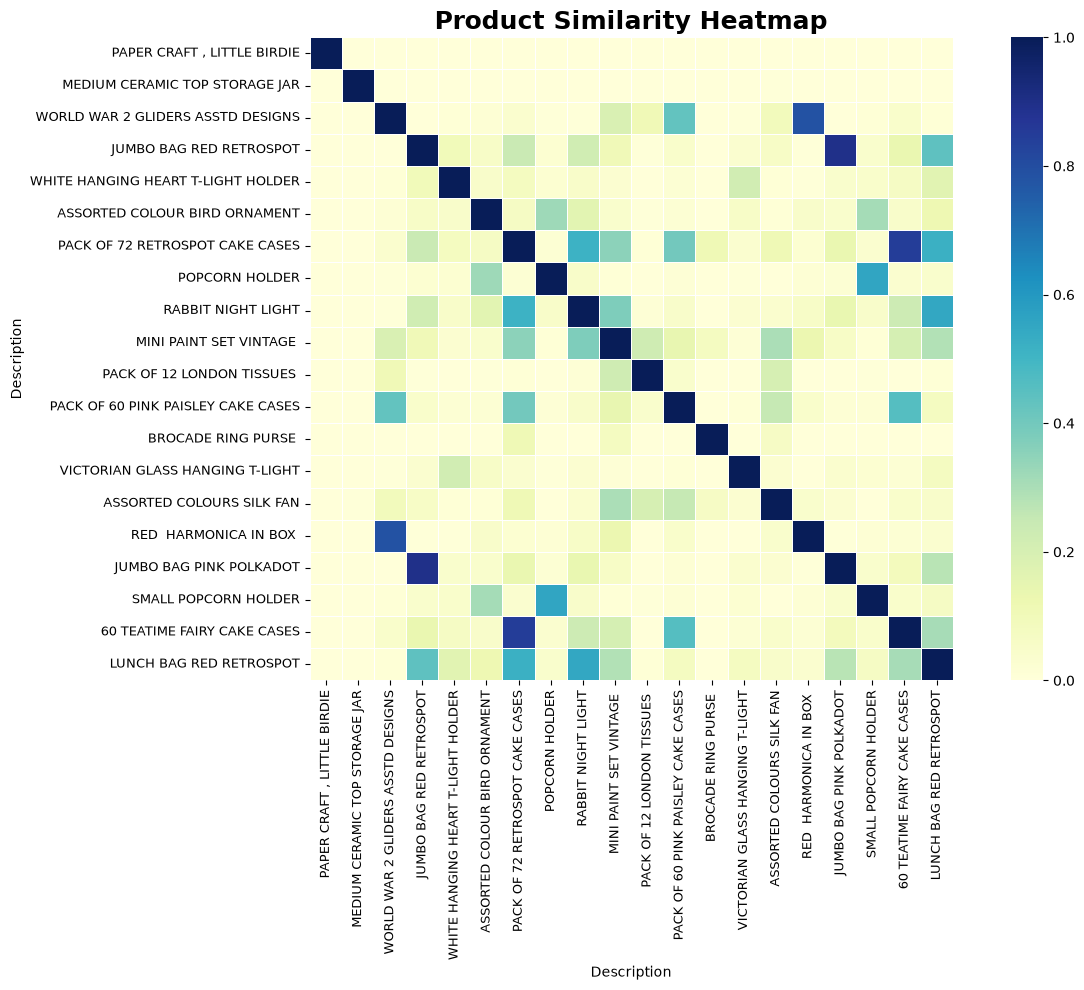

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 20 products
top20 = df.groupby('Description')['Quantity'].sum() \
          .sort_values(ascending=False) \
          .head(20).index

# Similarity matrix for top 20 products
heatmap_data = similarity_df.loc[top20, top20]

plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5,
    square=True
)

plt.title("Product Similarity Heatmap",
          fontsize=18,
          fontweight='bold')

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [90]:
def recommend_products(product_name, similarity_df, top_n=5):

    if product_name not in similarity_df.index:
        return ["Product not found"]

    recommendations = similarity_df[product_name] \
                        .sort_values(ascending=False)[1:top_n+1]

    return recommendations.index.tolist()

In [91]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER", similarity_df)

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']

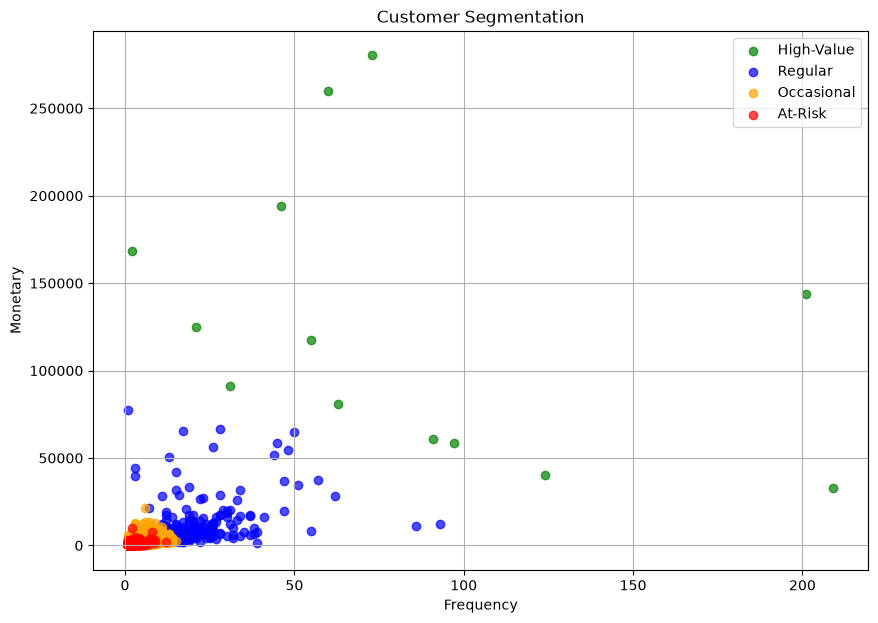

In [92]:
plt.figure(figsize=(10,7))

colors = {
    'High-Value':'green',
    'Regular':'blue',
    'Occasional':'orange',
    'At-Risk':'red'
}

for segment in colors:
    data = rfm[rfm['Customer Segment']==segment]

    plt.scatter(
        data['Frequency'],
        data['Monetary'],
        label=segment,
        color=colors[segment],
        alpha=0.7
    )

plt.title("Customer Segmentation")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend()

plt.grid(True)

plt.show()

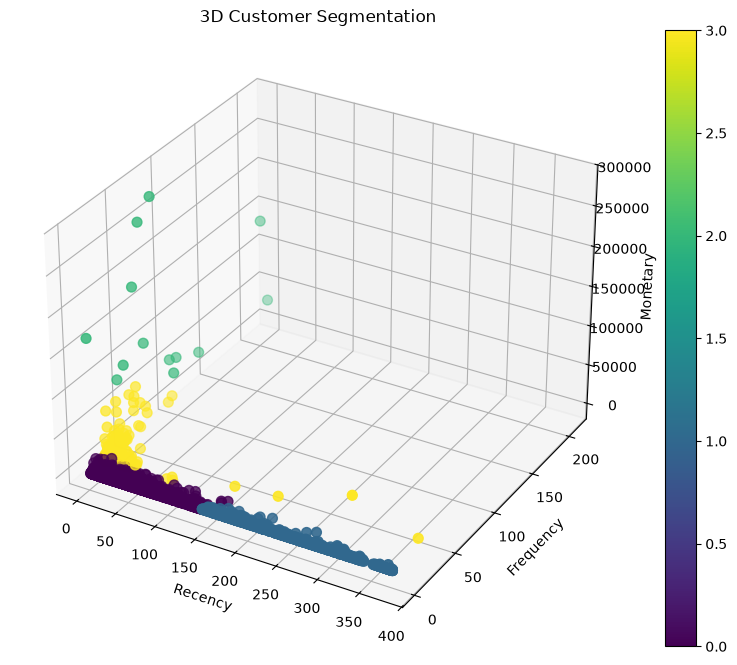

In [93]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    s=50
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segmentation")

plt.colorbar(scatter)

plt.show()

In [94]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [95]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [96]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(customer_product_matrix.T)

similarity_df = pd.DataFrame(
    similarity,
    index=customer_product_matrix.columns,
    columns=customer_product_matrix.columns
)

In [97]:
joblib.dump(similarity_df, "similarity.pkl")

['similarity.pkl']

In [98]:
def recommend_products(product_name, top_n=5):

    if product_name not in similarity_df.index:
        return "Product not found."

    recommendations = similarity_df[product_name].sort_values(ascending=False)

    return recommendations.iloc[1:top_n+1].index.tolist()